<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-01-21 18:21:18--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  67.4MB/s    in 2.3s    

2026-01-21 18:21:21 (67.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [117]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups

##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups

Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.

In [7]:
# 1. Group by 'Age' and calculate the median for the specific satisfaction columns
# This ensures that for each age group, we have a single representative score
df_jobsat = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

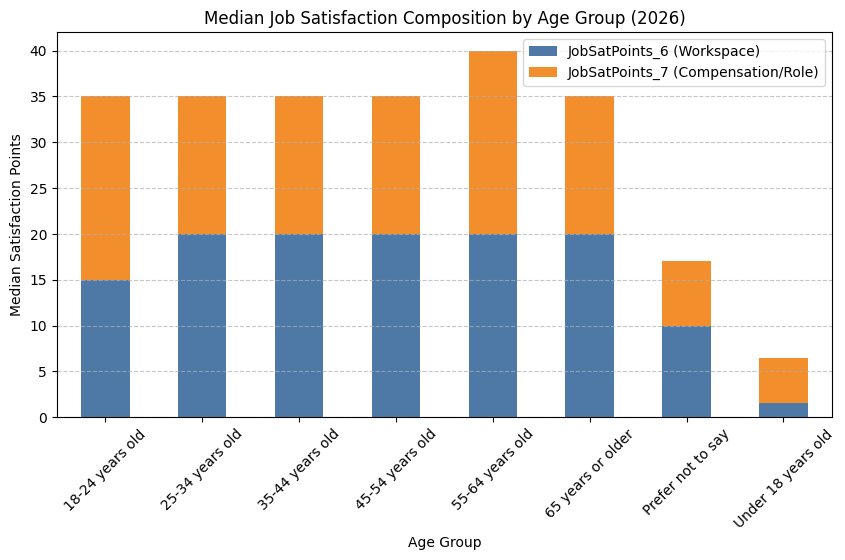

In [10]:
# 2. Plotting the stacked bar chart
# 'stacked=True' will place JobSatPoints_7 on top of JobSatPoints_6
df_jobsat.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#4e79a7', '#f28e2b'])
# 3. Customizing the chart for clarity
plt.title('Median Job Satisfaction Composition by Age Group (2026)')
plt.xlabel('Age Group')
plt.ylabel('Median Satisfaction Points')
plt.legend(['JobSatPoints_6 (Workspace)', 'JobSatPoints_7 (Compensation/Role)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


In [82]:
df_EmpSat = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']]
#df_EmpSat.head()

In [83]:
# 1. Split the strings by semicolon into lists
df_EmpSat['Employment'] = df_EmpSat['Employment'].str.split(';')

In [84]:
df_EmpSat = df_EmpSat.explode('Employment')

In [85]:
# 3. Standardize text (remove whitespace and standardize casing)
df_EmpSat['Employment'] = df_EmpSat['Employment'].str.strip().str.capitalize()

In [86]:
mapping = {
    'Employed, Full-Time': 'Full-time',
    'Employed, Part-Time': 'Part-time',
    'Independent contractor, freelancer, or self-employed': 'Contractor',
    'Not Employed, But Looking For Work': 'Unemployed',
    'Not employed, and not looking for work': 'Other',
    'Not employed, but looking for work': 'Look for Work',
    'Retired' : 'Retired'
}

# Replace specific substrings or exact matches
df_EmpSat['Employment'] = df_EmpSat['Employment'].replace(mapping, regex=True)

In [87]:
# Drop missing values for these specific columns to clean the plot
df_EmpSat = df_EmpSat.dropna(subset=['Employment', 'JobSatPoints_6', 'JobSatPoints_7'])
#df_EmpSat.head()

In [88]:
df_EmpSat = df_EmpSat.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()

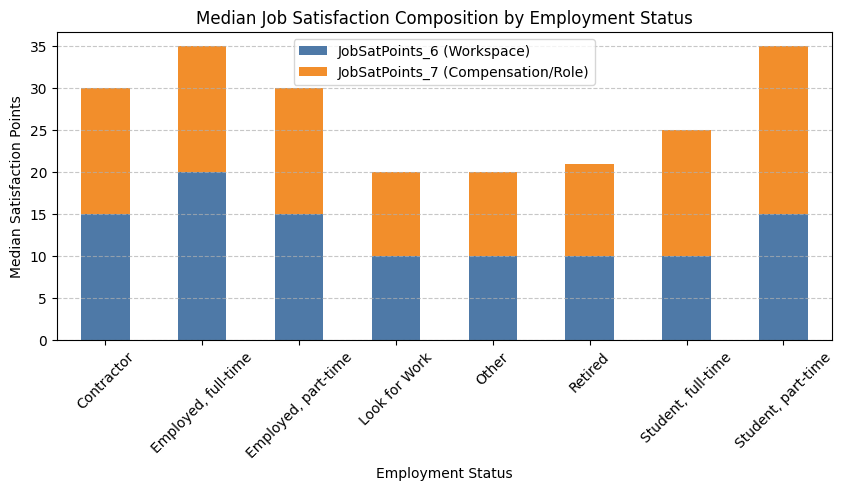

In [92]:
##Write your code here
# 2. Plotting the stacked bar chart
# 'stacked=True' will place JobSatPoints_7 on top of JobSatPoints_6
df_EmpSat.plot(kind='bar', stacked=True, figsize=(10, 4), color=['#4e79a7', '#f28e2b'])
# 3. Customizing the chart for clarity
plt.title('Median Job Satisfaction Composition by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Median Satisfaction Points')
plt.legend(['JobSatPoints_6 (Workspace)', 'JobSatPoints_7 (Compensation/Role)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


In [125]:
# 1. Filter for the 30-35 age group 
# (Commonly labeled '25-34 years' or '35-44 years' in 2026 developer datasets)
df_3035 = df[df['Age'].isin(['25-34 years old', '35-44 years old'])].copy()
#df_3035.head()

In [121]:
# 2. Calculate the Median values
median_comp = df_3035['ConvertedCompYearly'].median()
median_sat = df_3035['JobSatPoints_6'].median()

In [122]:
# 3. Define the "Maximums" to calculate percentage composition
# We use the 90th percentile for comp to avoid extreme outlier skew
max_comp_ref = df['ConvertedCompYearly'].quantile(0.9) 
max_sat_ref = 10 # Assuming JobSat is on a 1-10 scale

In [123]:
# 4. Convert to Percentages
comp_pct = (median_comp / max_comp_ref) * 100
sat_pct = (median_sat / max_sat_ref) * 100

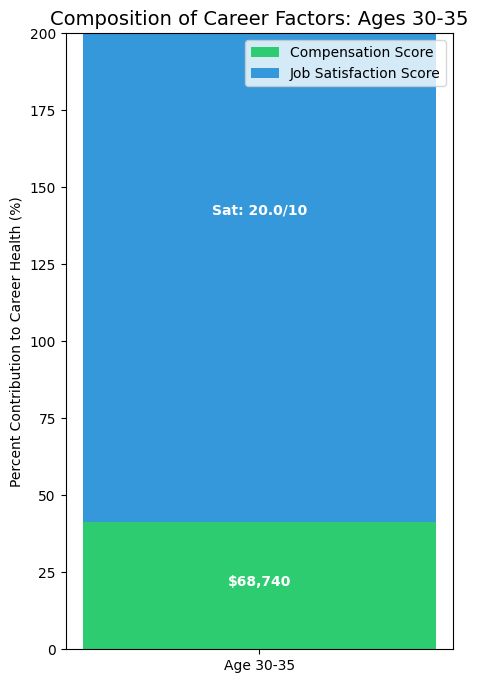

In [127]:
# 5. Create the Stacked Bar
plt.figure(figsize=(5, 8))
plt.bar(['Age 30-35'], [comp_pct], color='#2ecc71', label='Compensation Score')
plt.bar(['Age 30-35'], [sat_pct], bottom=[comp_pct], color='#3498db', label='Job Satisfaction Score')

# 6. Customization
plt.title('Composition of Career Factors: Ages 30-35', fontsize=14)
plt.ylabel('Percent Contribution to Career Health (%)')
plt.ylim(0, 200) # Since we are stacking two 100% scales
plt.legend()

# Add labels to show the actual raw values on the bars
plt.text(0, comp_pct/2, f'${median_comp:,.0f}', ha='center', color='white', fontweight='bold')
plt.text(0, comp_pct + (sat_pct/2), f'Sat: {median_sat}/10', ha='center', color='white', fontweight='bold')

plt.show()


##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


In [ ]:
##Write your code here

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [148]:
from collections import defaultdict
database_counts_by_age = defaultdict(lambda: defaultdict(int))

for index, row in df_AgeDB.iterrows():
    age_group = row['Age']
    if pd.notna(age_group) and pd.notna(row['DatabaseWantToWorkWith']):
        databases = row['DatabaseWantToWorkWith'].split(';')
        for db in databases:
            database_counts_by_age[age_group][db] += 1

In [149]:
# 3. Convert the counts into a Pandas DataFrame
counts_df = pd.DataFrame(database_counts_by_age).T.fillna(0)
# Sort columns to focus on the most popular databases overall for consistency
top_databases = counts_df.sum(axis=0).sort_values(ascending=False).head(5).index
counts_df = counts_df[top_databases]

In [150]:
# 4. Normalize the data by row (age group) to show proportions (%)
# Each age group's bars will sum to 100%
proportions_df = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

<Figure size 1000x400 with 0 Axes>

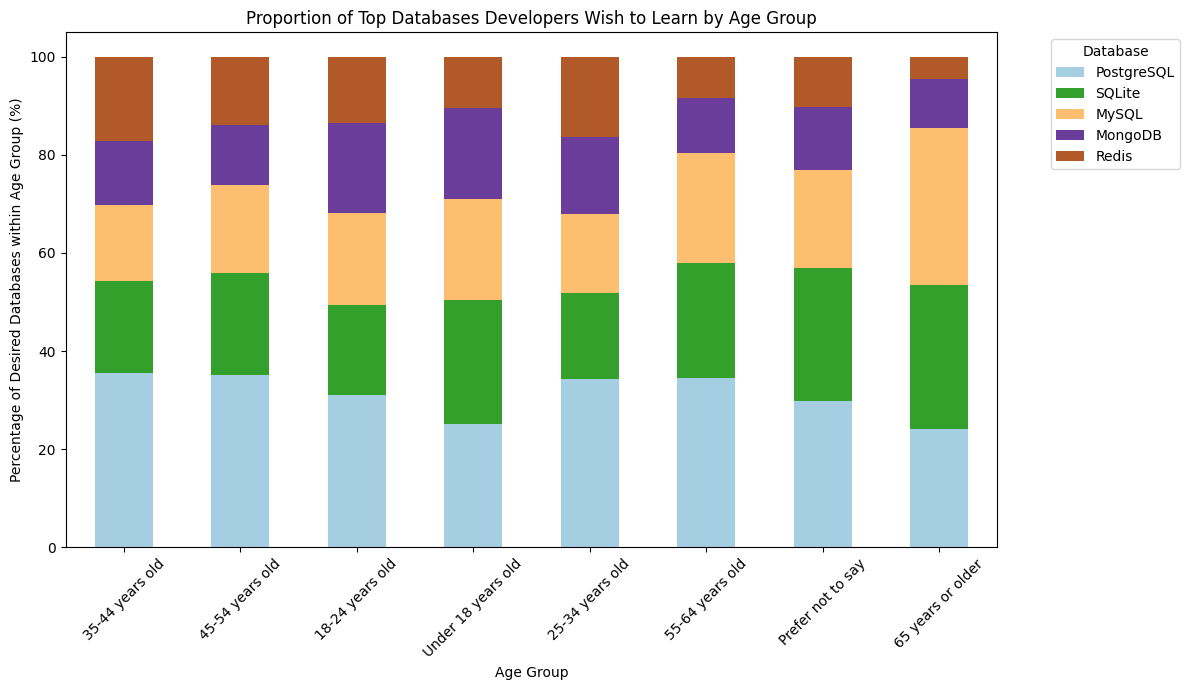

In [155]:
# --- Visualization ---
plt.figure(figsize=(10, 4))
# Use the proportions DataFrame for the stacked plot
proportions_df.plot(kind='bar', stacked=True, colormap='Paired', figsize=(12, 7))
plt.title('Proportion of Top Databases Developers Wish to Learn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Desired Databases within Age Group (%)')
plt.xticks(rotation=45)
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [156]:
# 1. Clean and Group Data
# Assuming 'JobSat' is the rating (1-10) and 'Employment' is the status
# We filter for relevant employment types to avoid a cluttered legend
main_employment = ['Employed, full-time', 'Independent contractor, freelancer, or self-employed', 'Employed, part-time']
df_filtered = df[df['Employment'].isin(main_employment)]

In [157]:
# 2. Create a Cross-tabulation of Job Satisfaction vs Employment
employment_dist = pd.crosstab(df_filtered['JobSat'], df_filtered['Employment'])

In [158]:
# 3. Normalize the data (100% Stacked)
# This ensures each bar sums to 1.0 (100%) to compare proportions directly
employment_pct = employment_dist.div(employment_dist.sum(axis=1), axis=0)

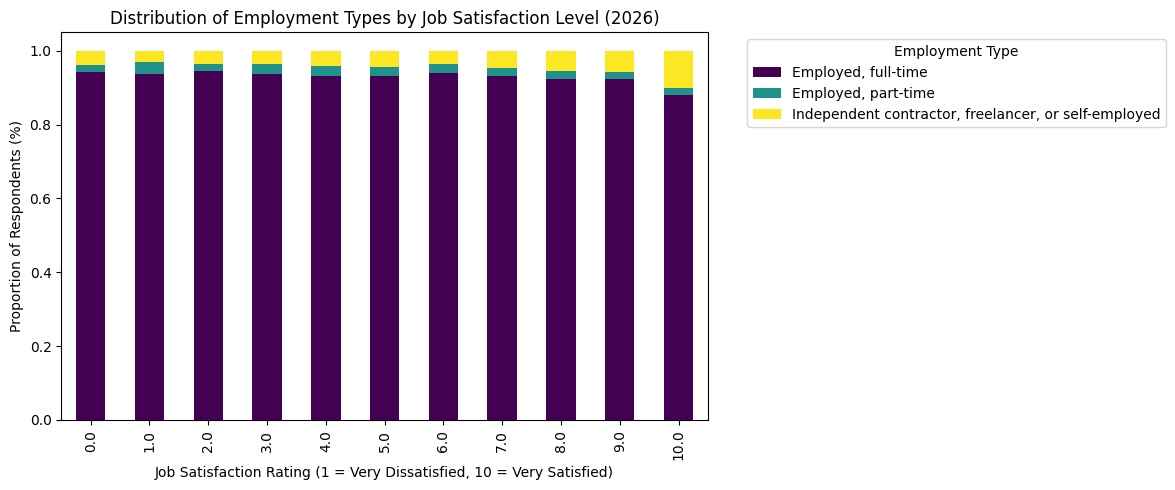

In [160]:
# 4. Plotting
ax = employment_pct.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='viridis')
# 5. Formatting
plt.title('Distribution of Employment Types by Job Satisfaction Level (2026)')
plt.xlabel('Job Satisfaction Rating (1 = Very Dissatisfied, 10 = Very Satisfied)')
plt.ylabel('Proportion of Respondents (%)')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


In [165]:
# 1. Prepare the data
# Explode the semicolon-separated languages so each choice has its own row
df_EmpSat = df[['Age', 'LanguageAdmired']].dropna()
df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.split(';')
df_exploded = df_lang.explode('LanguageAdmired')

In [166]:
# 2. Filter for Top 5 'Admired' Languages of 2026 for clarity
# Trends show Python, Rust, Go, TypeScript, and C++ are the major 2026 drivers
top_langs = ['Python', 'Rust', 'Go', 'TypeScript', 'C++']
df_filtered = df_exploded[df_exploded['LanguageAdmired'].isin(top_langs)]

In [174]:
#df_filtered.head()

In [171]:
# Reset the index to ensure every row has a unique identifier
df_filtered = df_filtered.reset_index(drop=True)

In [172]:
# 3. Create a Cross-tabulation and Normalize
# We normalize by age group (axis=0) to see the 'mix' of admiration within each demographic
ctab = pd.crosstab(df_filtered['Age'], df_filtered['LanguageAdmired'])
ctab_norm = ctab.div(ctab.sum(axis=0), axis=1) * 100

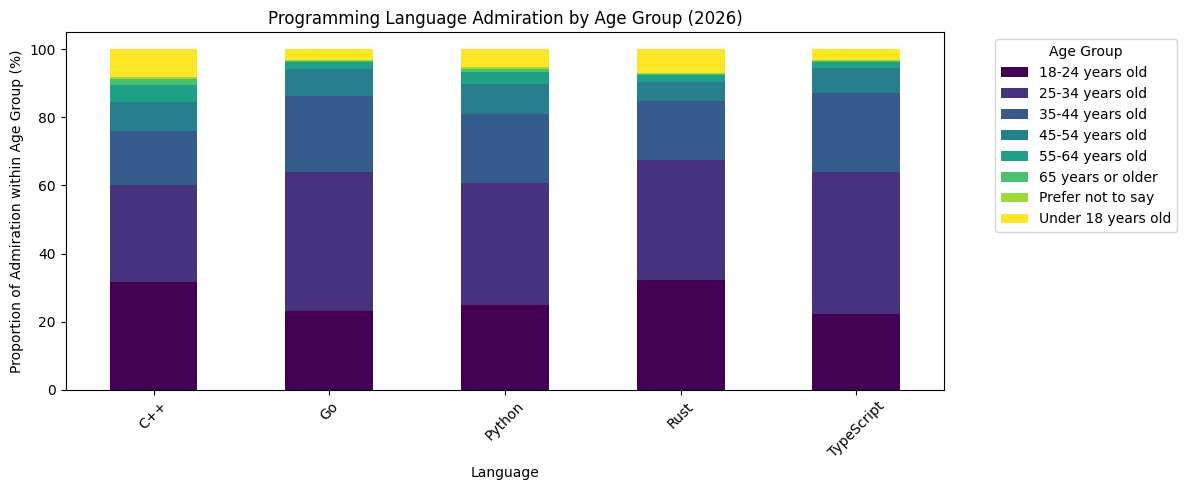

In [177]:
##Write your code here
# 4. Plot a Stacked Bar Chart
ax = ctab_norm.T.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='viridis')
plt.title('Programming Language Admiration by Age Group (2026)')
plt.ylabel('Proportion of Admiration within Age Group (%)')
plt.xlabel('Language')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [195]:
df_Emp = df[['Employment', 'PlatformAdmired']]
# 1. Split the strings by semicolon into lists
df_Emp['Employment'] = df_Emp['Employment'].str.split(';')

In [196]:
df_Emp = df_Emp.explode('Employment')

In [197]:
# 3. Standardize text (remove whitespace and standardize casing)
df_Emp['Employment'] = df_Emp['Employment'].str.strip().str.capitalize()

In [198]:
mapping = {
    'Employed, Full-Time': 'Full-time',
    'Employed, Part-Time': 'Part-time',
    'Independent contractor, freelancer, or self-employed': 'Contractor',
    'Not Employed, But Looking For Work': 'Unemployed',
    'Not employed, and not looking for work': 'Other',
    'Not employed, but looking for work': 'Look for Work',
    'Retired' : 'Retired'
}

# Replace specific substrings or exact matches
df_Emp['Employment'] = df_Emp['Employment'].replace(mapping, regex=True)

In [199]:
# Drop missing values for these specific columns to clean the plot
df_platforms = df_Emp[['Employment', 'PlatformAdmired']].dropna()
#df_EmpSat.head()

In [200]:
# 1. Prepare and Explode Data
# Semicolon-separated values are standard for 2026 developer survey schemas

df_platforms['PlatformAdmired'] = df_platforms['PlatformAdmired'].str.split(';')
# Reset index is CRITICAL after explode to prevent 'duplicate labels' errors
df_exploded = df_platforms.explode('PlatformAdmired').reset_index(drop=True)

In [201]:
# 2. Filter for Top Platforms (for cleaner visualization)
top_platforms = df_exploded['PlatformAdmired'].value_counts().nlargest(5).index
df_filtered = df_exploded[df_exploded['PlatformAdmired'].isin(top_platforms)]

In [202]:
# 3. Create Normalized Cross-tabulation
# This converts raw counts into percentages within each employment type
ctab = pd.crosstab(df_filtered['Employment'], df_filtered['PlatformAdmired'])
ctab_norm = ctab.div(ctab.sum(axis=1), axis=0) * 100

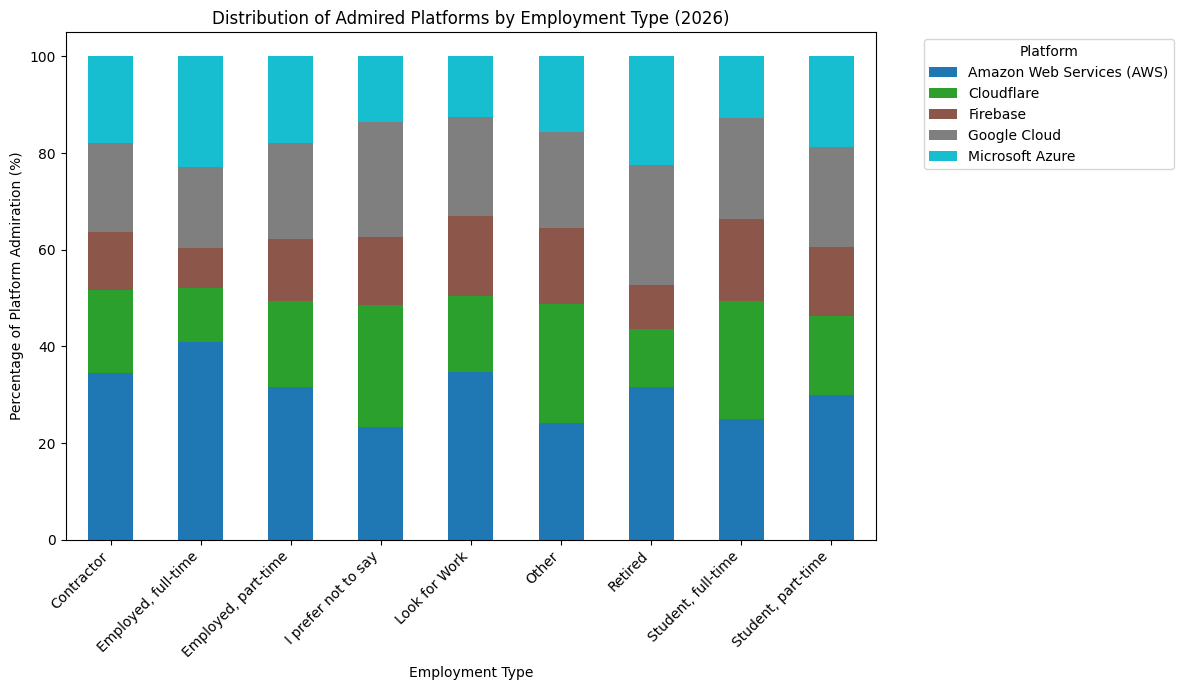

In [203]:
# Create a frequency table of Employment Status vs Admired Platforms
# 4. Plot the Stacked Bar Chart
ax = ctab_norm.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab10')

plt.title('Distribution of Admired Platforms by Employment Type (2026)')
plt.ylabel('Percentage of Platform Admiration (%)')
plt.xlabel('Employment Type')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
